<a href="https://colab.research.google.com/github/joamontesgi/seleccion_atributos/blob/main/Selecci%C3%B3n_de_caracter%C3%ADsticas_con_XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Pandas y numpy
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

!pip install ipython-autotime
%load_ext autotime

#Split para dividir el dataset
from sklearn.model_selection import train_test_split

#Se lee el dataset, el cual tiene 225745 registros
new_dataframe = pd.read_csv("/content/drive/MyDrive/Data/data.csv")

time: 5.3 s (started: 2022-03-30 21:19:17 +00:00)


In [ ]:
#Ataque DDoS = 0
new_dataframe[' Label'] = new_dataframe[' Label'].replace('DDoS',0)

#Tráfico benigno = 1
new_dataframe[' Label'] = new_dataframe[' Label'].replace('BENIGN',1)

#Eliminando valores infinitos
#new_dataframe = new_dataframe.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

#Pasando valores infinitos a NaN
new_dataframe.replace([np.inf, -np.inf], np.nan, inplace=True) 

#Eliminando valores NaN
new_dataframe=new_dataframe.dropna()
valoresNaN = new_dataframe.isnull().sum().sum()

#columna de salida
y = (new_dataframe[' Label'])

#Todas las columnas menos la de salida
X = new_dataframe.iloc[:,0:-1]

time: 645 ms (started: 2022-03-30 21:19:22 +00:00)


In [ ]:
X


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225740,61374,61,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225741,61378,72,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225742,61375,75,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225743,61323,48,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0


time: 208 ms (started: 2022-03-30 21:19:23 +00:00)


In [ ]:
#75% para entrenamiento (33861 registros), 25% para prueba (11288 registros)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

print('El total de registros de x para entrenamiento es :',(len(X_train)))
print('El total de registros de y para entrenamiento es :',(len(y_train)))
print('El total de registros de x para prueba es :',(len(X_test)))
print('El total de registros de y para prueba :',(len(y_test)))

El total de registros de x para entrenamiento es : 169283
El total de registros de y para entrenamiento es : 169283
El total de registros de x para prueba es : 56428
El total de registros de y para prueba : 56428
time: 202 ms (started: 2022-03-30 21:19:23 +00:00)


In [ ]:
X

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225740,61374,61,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225741,61378,72,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225742,61375,75,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225743,61323,48,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0


time: 69.1 ms (started: 2022-03-30 21:19:23 +00:00)


In [ ]:
#Eliminando espacios en blanco en los encabezados
new_dataframe.columns = new_dataframe.columns.str.strip()

time: 2.15 ms (started: 2022-03-30 21:19:23 +00:00)


In [ ]:
#Mostrando los encabezados
new_dataframe.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

time: 4.49 ms (started: 2022-03-30 21:19:23 +00:00)


In [ ]:
#Información sobre el dataframe
new_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 225711 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             225711 non-null  int64  
 1   Flow Duration                225711 non-null  int64  
 2   Total Fwd Packets            225711 non-null  int64  
 3   Total Backward Packets       225711 non-null  int64  
 4   Total Length of Fwd Packets  225711 non-null  int64  
 5   Total Length of Bwd Packets  225711 non-null  int64  
 6   Fwd Packet Length Max        225711 non-null  int64  
 7   Fwd Packet Length Min        225711 non-null  int64  
 8   Fwd Packet Length Mean       225711 non-null  float64
 9   Fwd Packet Length Std        225711 non-null  float64
 10  Bwd Packet Length Max        225711 non-null  int64  
 11  Bwd Packet Length Min        225711 non-null  int64  
 12  Bwd Packet Length Mean       225711 non-null  float64
 13 

In [ ]:
X

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225740,61374,61,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225741,61378,72,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225742,61375,75,1,1,6,6,6,6,6.0,0.0,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
225743,61323,48,2,0,12,0,6,6,6.0,0.0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0


time: 77.3 ms (started: 2022-03-30 21:19:24 +00:00)


Puntuación de precisión del modelo con hiperparámetros por defecto 1.0000
Puntuación de exhaustividad  del modelo con hiperparámetros por defecto 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32141
           1       1.00      1.00      1.00     24287

    accuracy                           1.00     56428
   macro avg       1.00      1.00      1.00     56428
weighted avg       1.00      1.00      1.00     56428



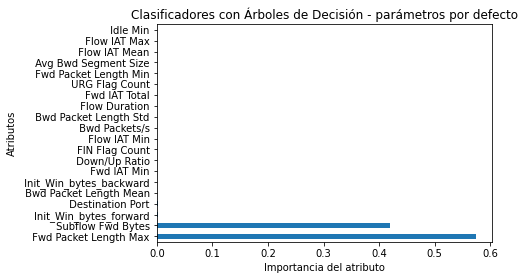

time: 5.93 s (started: 2022-03-30 21:19:24 +00:00)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()
clf.fit(X, y)
y_pred=clf.predict(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

print('Puntuación de precisión del modelo con hiperparámetros por defecto {0:0.4f}'. format(accuracy_score(y_test, y_pred)))
print('Puntuación de exhaustividad  del modelo con hiperparámetros por defecto {0:0.4f}'. format(recall_score(y_test, y_pred)))
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



feat_importances = pd.Series(clf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.title("Clasificadores con Árboles de Decisión - parámetros por defecto")
plt.xlabel("Importancia del atributo")
plt.ylabel("Atributos")
plt.show()




In [ ]:
feature_importances=pd.DataFrame({'Atributos':X.columns,'Importancia del atributo':clf.feature_importances_})
atributos=(feature_importances.sort_values('Importancia del atributo',ascending=False))
atributos.head(n=78)

,Atributos,Importancia del atributo
6,Fwd Packet Length Max,0.573573
63,Subflow Fwd Bytes,0.419894
66,Init_Win_bytes_forward,0.002292
0,Destination Port,0.001249
12,Bwd Packet Length Mean,0.000809
...,...,...
44,SYN Flag Count,0.000000
45,RST Flag Count,0.000000
46,PSH Flag Count,0.000000
47,ACK Flag Count,0.000000


time: 22.7 ms (started: 2022-03-30 21:19:30 +00:00)


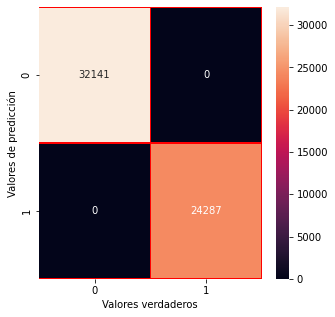

time: 641 ms (started: 2022-03-30 21:19:30 +00:00)


In [ ]:
#confusion matrix visualization
import seaborn as sns
import matplotlib.pyplot as plt

y_pred=clf.predict(X_test)
y_true=y_test


from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_true,y_pred)
cm

f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("Valores verdaderos")
plt.ylabel("Valores de predicción")
plt.show()

Puntuación de precisión del modelo con hiperparámetros por defecto 0.9998
Puntuación de exhaustividad  del modelo con hiperparámetros por defecto 0.9999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32141
           1       1.00      1.00      1.00     24287

    accuracy                           1.00     56428
   macro avg       1.00      1.00      1.00     56428
weighted avg       1.00      1.00      1.00     56428



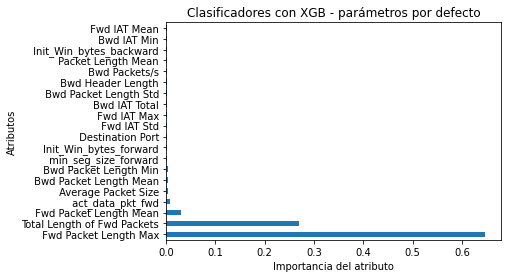

time: 1min 13s (started: 2022-03-30 21:19:30 +00:00)


In [ ]:
#Importando el XGBClassifier
from xgboost import XGBClassifier

model=XGBClassifier()
model.fit(X,y)
y_pred=model.predict(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

print('Puntuación de precisión del modelo con hiperparámetros por defecto {0:0.4f}'. format(accuracy_score(y_test, y_pred)))
print('Puntuación de exhaustividad  del modelo con hiperparámetros por defecto {0:0.4f}'. format(recall_score(y_test, y_pred)))
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.title("Clasificadores con XGB - parámetros por defecto")
plt.xlabel("Importancia del atributo")
plt.ylabel("Atributos")
plt.show()

In [ ]:
feature_importances=pd.DataFrame({'Atributos':X.columns,'Importancia del atributo':model.feature_importances_})
atributos=(feature_importances.sort_values('Importancia del atributo',ascending=False))
atributos.head(n=78)


,Atributos,Importancia del atributo
6,Fwd Packet Length Max,0.646045
4,Total Length of Fwd Packets,0.270044
8,Fwd Packet Length Mean,0.030158
68,act_data_pkt_fwd,0.008049
52,Average Packet Size,0.003850
...,...,...
45,RST Flag Count,0.000000
46,PSH Flag Count,0.000000
49,CWE Flag Count,0.000000
50,ECE Flag Count,0.000000


time: 17.8 ms (started: 2022-03-30 21:20:43 +00:00)


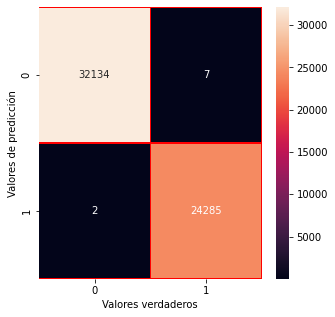

time: 385 ms (started: 2022-03-30 21:20:43 +00:00)


In [ ]:
#confusion matrix visualization
import seaborn as sns
import matplotlib.pyplot as plt

y_pred=model.predict(X_test)
y_true=y_test


from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_true,y_pred)
cm

f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("Valores verdaderos")
plt.ylabel("Valores de predicción")
plt.show()

In [ ]:
new_x=new_dataframe.loc[:, ['Fwd Packet Length Max', 'Total Length of Fwd Packets', 'Fwd Packet Length Mean']]
new_y = (new_dataframe['Label'])

X1_train, X1_test, y1_train, y1_test = train_test_split(new_x, new_y, test_size = 0.25, random_state = 0)

print('El total de registros de x para entrenamiento es :',(len(X1_train)))
print('El total de registros de y para entrenamiento es :',(len(y1_train)))
print('El total de registros de x para prueba es :',(len(X1_test)))
print('El total de registros de y para prueba :',(len(y1_test)))
new_x.head()

El total de registros de x para entrenamiento es : 169283
El total de registros de y para entrenamiento es : 169283
El total de registros de x para prueba es : 56428
El total de registros de y para prueba : 56428


,Fwd Packet Length Max,Total Length of Fwd Packets,Fwd Packet Length Mean
0,6,12,6.0
1,6,6,6.0
2,6,6,6.0
3,6,6,6.0
4,6,12,6.0


time: 54.4 ms (started: 2022-03-30 21:20:44 +00:00)


In [ ]:
print(X1_train.shape); print(X1_test.shape)

(169283, 3)
(56428, 3)
time: 2.74 ms (started: 2022-03-30 21:20:44 +00:00)


Puntuación de precisión del modelo con hiperparámetros por defecto 0.9977
[[32107    34]
 [   98 24189]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32141
           1       1.00      1.00      1.00     24287

    accuracy                           1.00     56428
   macro avg       1.00      1.00      1.00     56428
weighted avg       1.00      1.00      1.00     56428



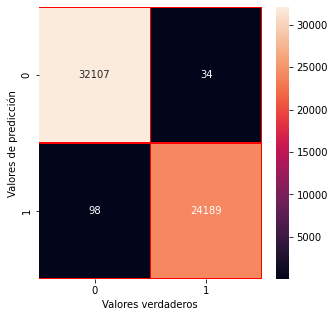

time: 24.2 s (started: 2022-03-30 21:20:44 +00:00)


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp1 = MLPClassifier(hidden_layer_sizes=(3,4,1), activation='relu', solver='adam', max_iter=15000)
mlp1.fit(X1_train,y1_train)



predict_train = mlp1.predict(X1_train)
predict_test = mlp1.predict(X1_test)

print('Puntuación de precisión del modelo con hiperparámetros por defecto {0:0.4f}'. format(accuracy_score(y1_test, predict_test)))

print(confusion_matrix(y1_test,predict_test))
print(classification_report(y1_test,predict_test))

#confusion matrix visualization
import seaborn as sns
import matplotlib.pyplot as plt



from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y1_test,predict_test)
cm

f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("Valores verdaderos")
plt.ylabel("Valores de predicción")
plt.show()


Puntuación de precisión del modelo con hiperparámetros por defecto 0.9983
[[32081    60]
 [   37 24250]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32141
           1       1.00      1.00      1.00     24287

    accuracy                           1.00     56428
   macro avg       1.00      1.00      1.00     56428
weighted avg       1.00      1.00      1.00     56428



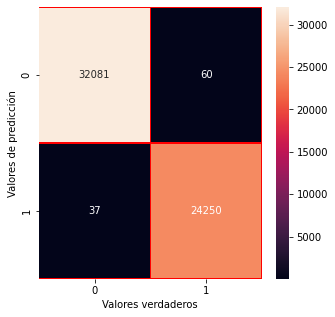

time: 19.3 s (started: 2022-03-30 21:21:08 +00:00)


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp2 = MLPClassifier(hidden_layer_sizes=(3,5,1), activation='logistic', solver='lbfgs', max_iter=50000)
mlp2.fit(X1_train,y1_train)



predict_train = mlp2.predict(X1_train)
predict_test = mlp2.predict(X1_test)

print('Puntuación de precisión del modelo con hiperparámetros por defecto {0:0.4f}'. format(accuracy_score(y1_test, predict_test)))

print(confusion_matrix(y1_test,predict_test))
print(classification_report(y1_test,predict_test))

#confusion matrix visualization
import seaborn as sns
import matplotlib.pyplot as plt



from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y1_test,predict_test)
cm

f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("Valores verdaderos")
plt.ylabel("Valores de predicción")
plt.show()

Puntuación de precisión del modelo con hiperparámetros por defecto 0.5696
[[32141     0]
 [24287     0]]
              precision    recall  f1-score   support

           0       0.57      1.00      0.73     32141
           1       0.00      0.00      0.00     24287

    accuracy                           0.57     56428
   macro avg       0.28      0.50      0.36     56428
weighted avg       0.32      0.57      0.41     56428



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


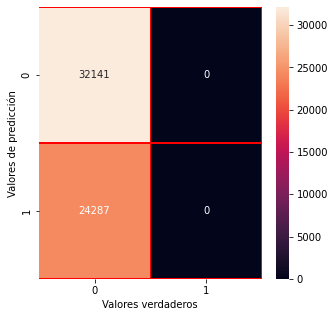

time: 8.13 s (started: 2022-03-30 21:21:27 +00:00)


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp3 = MLPClassifier(hidden_layer_sizes=(3,6,1), activation='relu', solver='adam', max_iter=15000)
mlp3.fit(X1_train,y1_train)



predict_train = mlp3.predict(X1_train)
predict_test = mlp3.predict(X1_test)

print('Puntuación de precisión del modelo con hiperparámetros por defecto {0:0.4f}'. format(accuracy_score(y1_test, predict_test)))

print(confusion_matrix(y1_test,predict_test))
print(classification_report(y1_test,predict_test))

#confusion matrix visualization
import seaborn as sns
import matplotlib.pyplot as plt



from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y1_test,predict_test)
cm

f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("Valores verdaderos")
plt.ylabel("Valores de predicción")
plt.show()

In [ ]:
#Hiperparámetros por defecto

# import SVC classifier
from sklearn.svm import SVC

# import metrics to compute accuracy
from sklearn.metrics import accuracy_score

# instantiate classifier with default hyperparameters
svc=SVC() 

# fit classifier to training set
model_svc=svc.fit(X1_train,y1_train)

# make predictions on test set
y_pred_svc=svc.predict(X1_test)

# compute and print accuracy score
print('Puntuación de precisión del modelo con hiperparámetros por defecto: {0:0.4f}'. format(accuracy_score(y1_test, y_pred_svc)))

Puntuación de precisión del modelo con hiperparámetros por defecto: 0.8590
time: 28min 29s (started: 2022-03-30 21:21:36 +00:00)


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y1_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     32141
           1       1.00      0.67      0.80     24287

    accuracy                           0.86     56428
   macro avg       0.90      0.84      0.85     56428
weighted avg       0.89      0.86      0.85     56428

time: 119 ms (started: 2022-03-30 21:50:05 +00:00)


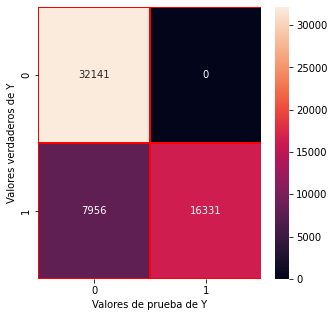

time: 4min 21s (started: 2022-03-30 21:50:05 +00:00)


In [ ]:
#confusion matrix visualization
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_svc=model_svc.predict(X1_test)
y_true_vsc=y1_test


from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_true_vsc,y_pred_svc)
cm

f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("Valores de prueba de Y")
plt.ylabel("Valores verdaderos de Y")
plt.show()

In [ ]:
X1_train

,Fwd Packet Length Max,Total Length of Fwd Packets,Fwd Packet Length Mean
128255,41,41,41.000000
150475,20,56,7.000000
4162,33,66,33.000000
29757,20,56,7.000000
62658,20,26,8.666667
...,...,...,...
176983,6,6,6.000000
117968,20,26,8.666667
173703,33,66,33.000000
43580,20,26,8.666667


time: 11.4 ms (started: 2022-03-30 21:54:27 +00:00)
